<a href="https://colab.research.google.com/github/priyalimbu246/assignments/blob/main/Copy_of_Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Chemical Applications of Machine Learning (CHEM 4930/5610) - Spring 2026

### Assignment 5 - Deadline 4/6/2026
Points 10

#### General Comments
All figures and graph should have approriate labels on the two axis, and should include a legend with appropriate labels of the different plots.

The notebook should be return in working format. That is, I should be able to reset all the output and re-run all the cells and get the same results as you obtained.

**You should start by saving a copy of the notebook to your Google Drive so you preserve all changes.**

**Please add your name as a suffix to the filname**

**Student Name**: Priya Limbu

**AI usage statement:**
I have used perplexicity and claude for understanding of code and shortining the codes.

### Task 1 - 10 points

Here we consider a alanine dipeptide in vacuum that is simple model often used to test methods. It consists of one alanine (Ala) residues and capping group. It is conformational dynamics can be understood in terms of the backbone dihedral angles $\Phi$ and $\Psi$.

![Alanine Dipeptide](https://github.com/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/blob/main/Assignment-5/AlanineDipeptideVac-1.png?raw=true)

The free energy landscape/surface $F(\Phi,\Psi)$ (see figure above) as function of $\Phi$ and $\Psi$ is known as the [Ramachandran plot](https://en.wikipedia.org/wiki/Ramachandran_plot). Note that here we are considering the system in vacuum so the energy landscape is different from what one would expect in solvent.

This system has two states, $C_{7\mathrm{eq}}$ and $C_{7\mathrm{ax}}$, where the $C_{7\mathrm{eq}}$ state is more populated one (i.e., lower in free energy).

Note that free energy landscape/surface $F(\Phi,\Psi)$ is related to the probability density function $P(\Phi,\Psi)$ through the following equation:

$$
F(\Phi,\Psi) = -k_{\mathrm{B}} T \ln P(\Phi,\Psi) + C
$$

where $T$ is the temperature, $k_{\mathrm{B}}$ is the Boltzmann constant, so that $k_{\mathrm{B}} T$ is the thermal energy, and $C$ is an unimportant constant. We also have that

$$
P(\Phi,\Psi) \propto \exp[-\beta F(\Phi,\Psi) ]
$$

where $\beta = (k_{\mathrm{B}} T)^{-1}$ is the inverse of the thermal energy.

We will consider dataset from molecular dynamics simulations, in particular parallel tempering (PT) simulations, that should give correct equilibrium sampling according to the Boltzmann distribution.

The dataset we consider is at temperture of 576 K. It is from a 100 ns PT simulations where we save variables every 10 ps, so we have 10000 samples.

The dataset is composed of two files. The `AlanineDipeptide_T-576K_Dihedrals.data` file includes the dihedral angles, $\Phi$, $\Psi$, $\Theta$. The `AlanineDipeptide_T-576K_HeavyAtomDistances.data` file includes all possible pairs of heavy atom distances (there are 10 heavy atoms, so the number of all possible pairs is $(10\cdot 9)/2 = 45$).

#### A)
Visualize the dataset in terms of the backbone dihedral angles $\Phi$ and $\Psi$. You should look at the timeseries and a 2D scatter plots.

You should estimate and visualize the 1D probability density for $\Phi$ and $\Psi$, and also the 2D probability density for $\Phi$ and $\Psi$.

Optional: You will get 1 extra point if you correctly handle the periodicity of the dihedral angles when estimating the 1D and 2D probability densities.

#### B)
Design criteria so that you can assign each sample from the dataset to either the $C_{7\mathrm{eq}}$ or the $C_{7\mathrm{ax}}$ state. You should use this later on to check if the embedding that you obtain correctly seperate the two differnet states.

Note: This criteria should be more advanced than what we did in Lecture 16 where we only considered if $\Phi$ was postive.

#### C)
Perform Principal Component Analysis (PCA) for the system using all heavy atom distances as input features, and visualize the first two principle components.

Here, you should use the full dataset in the analysis (all 10000 samples).

How much of the variance is described by the first two principle components?

Use the results from B) to understand if the PCA embeddings is able to seperate the $C_{7\mathrm{eq}}$ and $C_{7\mathrm{ax}}$ states.

You should try both using unscaled and scaled distances as input features. How does this affect the results.

#### D)
Some of the heavy atom distances might not be relevant and only add noise. To address this, design criteria for filtering out distances that might not be relevant and re-do the PCA analysis. How does this affect the results?

For example, you might consider only using distances that have standard deviation above some given threshold value.

#### E)
Perform *t*-SNE analysis using the [openTSNE](https://opentsne.readthedocs.io/en/stable/index.html) code and obtain two-dimensional embeddings.

One feature of the openTNSE implementation of *t*-SNE, as compared to the scikit-learn one, is that it allows for embedding new samples into existing embeddings.

Here, you should use 10% of the dataset (1000 samples) to fit the $t$-SNE embedding (for example by taking only every 10 sample), and then transform the full dataset and plot and visulize that.

Here, you should use the set of filtered distances that you used in D). I would also recommend to use scaled distances.

Here, you should consider different perplexity values in the analysis. What is optimal perplexity value in your opinion?

Once you have found the optimal perplexity value, you can you try to use the full dataset in the fitting of the $t$-SNE embedding. The openTNSE implementation should more performant thant the scikit-learn one. Does this affect the results in some manner.

#### F) - Optional for 2 point
For the *t*-SNE analysis, using the the optimal perplexity value, test the effect of 1) using either unscaled or scaled features; and 2) using either the filtered distances or the full set of 45 distances.

In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [155]:
%%bash
datasets="
AlanineDipeptide_T-576K_Dihedrals.data
AlanineDipeptide_T-576K_HeavyAtomDistances.data
"

url="https://raw.githubusercontent.com/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/refs/heads/main/Assignment-5/Datasets"

for d in ${datasets}
do
    curl -O "${url}/${d}" &> /dev/null
done

ls

AlanineDipeptide_T-576K_Dihedrals.data
AlanineDipeptide_T-576K_Dihedrals.data.1
AlanineDipeptide_T-576K_Dihedrals.data.2
AlanineDipeptide_T-576K_HeavyAtomDistances.data
AlanineDipeptide_T-576K_HeavyAtomDistances.data.1
AlanineDipeptide_T-576K_HeavyAtomDistances.data.2
sample_data


#A
Visualize the dataset in terms of the backbone dihedral angles  Φ and  Ψ . You should look at the timeseries and a 2D scatter plots.

You should estimate and visualize the 1D probability density for  Φ  and  Ψ , and also the 2D probability density for  Φ  and  Ψ .

Optional: You will get 1 extra point if you correctly handle the periodicity of the dihedral angles when estimating the 1D and 2D probability densities.

In [156]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [157]:
!head AlanineDipeptide_T-576K_Dihedrals.data

#! FIELDS time phi psi theta
#! SET min_phi -pi
#! SET max_phi pi
#! SET min_psi -pi
#! SET max_psi pi
#! SET min_theta -pi
#! SET max_theta pi
 0.000000 -1.141704 1.082064 -0.210466
 10.000000 -1.369176 1.979026 0.140964
 20.000001 -1.438536 1.399407 -0.021412


In [158]:
def get_variables_names_from_header(filename):
  with open(filename, 'r') as f:
    header = f.readline()
    variables = header.split()[2:]
  return variables

In [159]:

dih_variables = get_variables_names_from_header("AlanineDipeptide_T-576K_Dihedrals.data") # theta is equivalent to omega
print(dih_variables)

data_dih = pd.read_csv("AlanineDipeptide_T-576K_Dihedrals.data", header=None, names=dih_variables, sep='\s+', comment="#")

# only take every N-th value
stride = 1
data_dih = data_dih.iloc[::stride]
# this is to reset the index
data_dih.reset_index(drop=True, inplace=True)

['time', 'phi', 'psi', 'theta']


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7011/3031677667.py:4: SyntaxWarning: invalid escape sequence '\s'
  data_dih = pd.read_csv("AlanineDipeptide_T-576K_Dihedrals.data", header=None, names=dih_variables, sep='\s+', comment="#")


In [160]:
data_dih

,time,phi,psi,theta
0,0.000000,-1.141704,1.082064,-0.210466
1,10.000000,-1.369176,1.979026,0.140964
2,20.000001,-1.438536,1.399407,-0.021412
3,30.000001,-1.164418,2.531988,-0.247547
4,40.000002,-1.925286,3.103990,0.350282
...,...,...,...,...
9996,99960.004748,-2.064676,2.806661,-0.110477
9997,99970.004748,-1.879789,0.638437,0.298196
9998,99980.004749,1.706245,-1.761336,-0.369171
9999,99990.004749,0.972262,-0.610753,0.348669


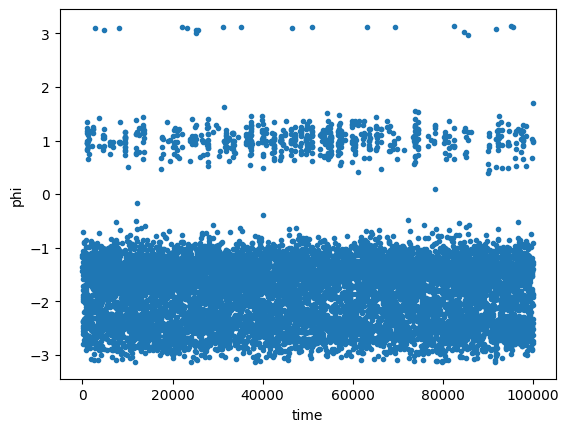

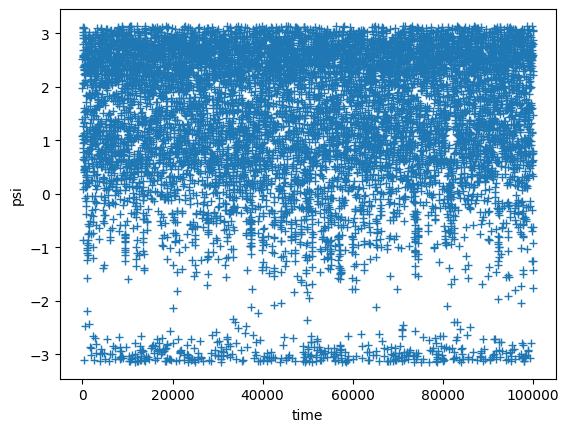

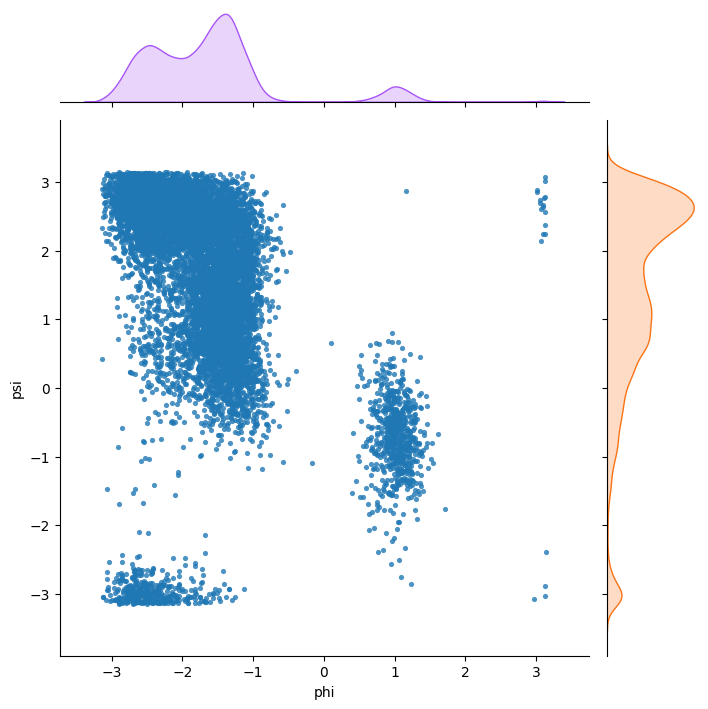

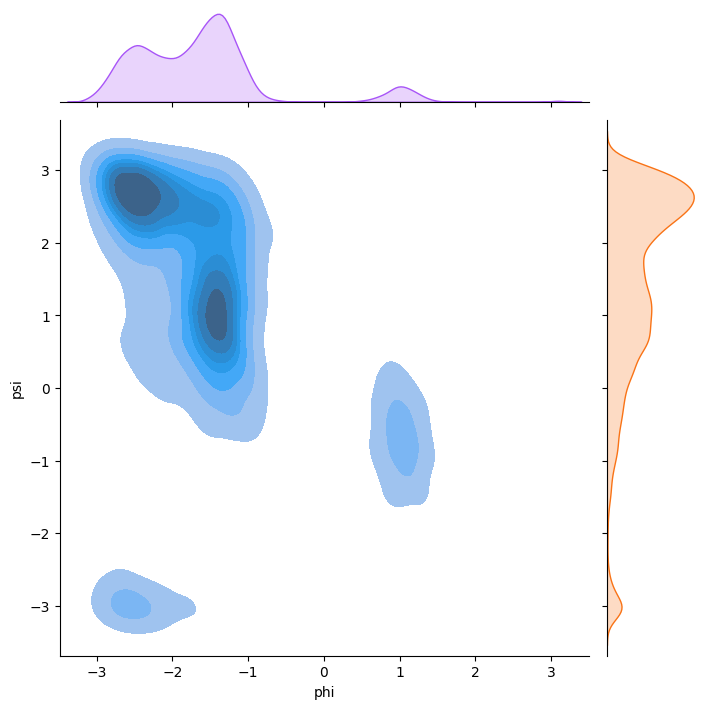

In [161]:
x_label = 'phi'
y_label = 'psi'

t = data_dih['time']
x = data_dih[x_label]
y = data_dih[y_label]


plt.plot(t, x, '.', label='x')
plt.xlabel('time')
plt.ylabel(x_label)
plt.show()

plt.plot(t, y, '+', label='y')
plt.xlabel('time')
plt.ylabel(y_label)
plt.show()

g = sns.JointGrid(height=7, ratio=5)
ax_scatter, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
sc = ax_scatter.scatter(x, y, s=14, alpha=0.8, linewidths=0)
ax_scatter.set_xlabel(x_label)
ax_scatter.set_ylabel(y_label)
sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
plt.show()

g = sns.JointGrid(height=7, ratio=5)
ax_joint, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
sns.kdeplot(x=x, y=y,
            ax=ax_joint,
            bw_adjust=0.6,
            fill=True,
            levels=8)
ax_joint.set_xlabel(x_label)
ax_joint.set_ylabel(y_label)
sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
plt.show()

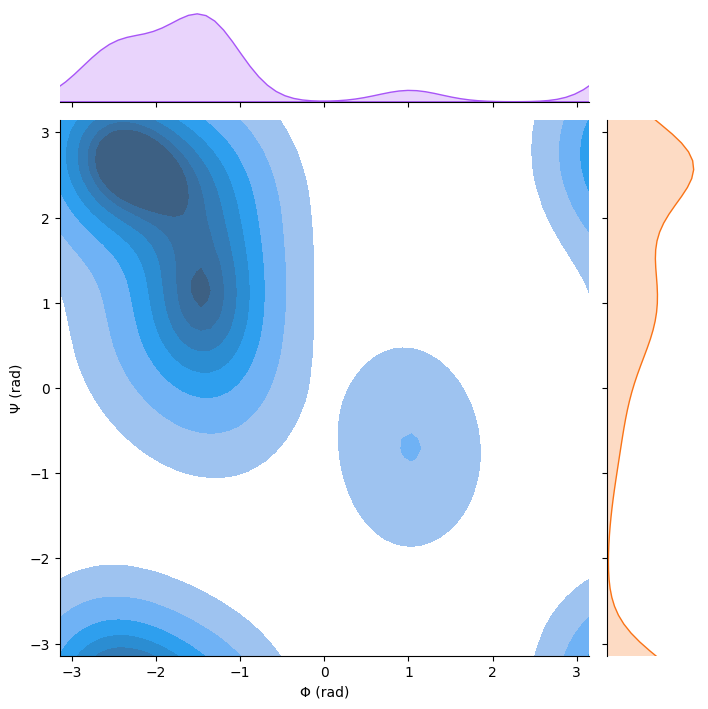

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

stride=1

data = np.vstack([data_dih['phi'],data_dih['psi']])

periodic_variables = True

if periodic_variables:
  # Tile data in both dimensions
  shifts = [-2*np.pi, 0, 2*np.pi]
  tiled_data = []
  for dx in shifts:
      for dy in shifts:
          shifted = np.vstack([data_dih['phi'] + dx, data_dih['psi'] + dy])
          tiled_data.append(shifted)

  data_used = np.hstack(tiled_data)
else:
  data_used = data

data_used = data_used[:,::stride]

x = data_used[0]
y = data_used[1]

g = sns.JointGrid(height=7, ratio=5)
ax_joint, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
sns.kdeplot(x=x, y=y,
            ax=ax_joint,
            bw_adjust=0.6,
            fill=True,
            levels=8)
ax_joint.set_xlabel(x_label)
ax_joint.set_ylabel(y_label)
sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
ax_joint.set_xlim(-np.pi, np.pi)
ax_joint.set_ylim(-np.pi, np.pi)
ax_top.set_xlim(-np.pi, np.pi)
ax_right.set_ylim(-np.pi, np.pi)
plt.show()


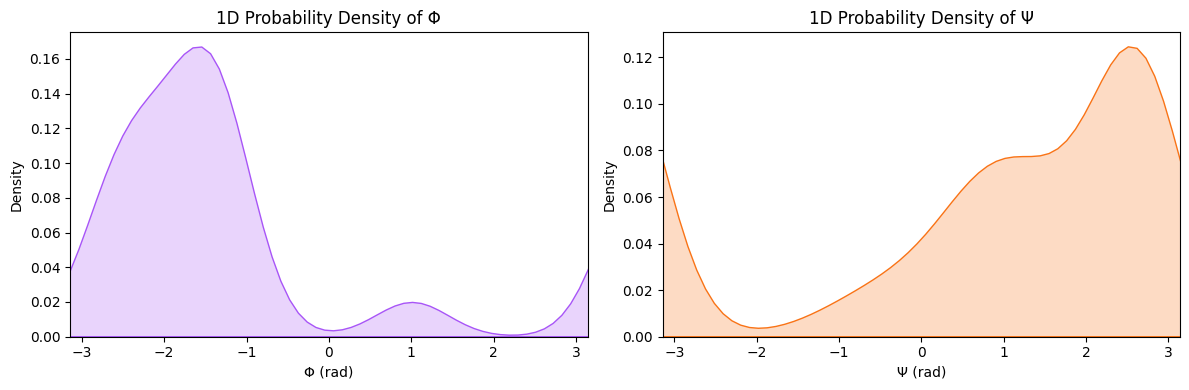

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

x_label = 'Φ (rad)'
y_label = 'Ψ (rad)'

# Periodic tiling for 1D
shifts = [-2*np.pi, 0, 2*np.pi]

phi_tiled = np.concatenate([data_dih['phi'] + s for s in shifts])
psi_tiled = np.concatenate([data_dih['psi'] + s for s in shifts])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(x=phi_tiled, ax=axes[0], fill=True, color="#a855f7", bw_adjust=0.6)
axes[0].set_xlim(-np.pi, np.pi)
axes[0].set_xlabel(x_label)
axes[0].set_ylabel('Density')
axes[0].set_title('1D Probability Density of Φ')

sns.kdeplot(x=psi_tiled, ax=axes[1], fill=True, color="#f97316", bw_adjust=0.6)
axes[1].set_xlim(-np.pi, np.pi)
axes[1].set_xlabel(y_label)
axes[1].set_ylabel('Density')
axes[1].set_title('1D Probability Density of Ψ')

plt.tight_layout()
plt.show()

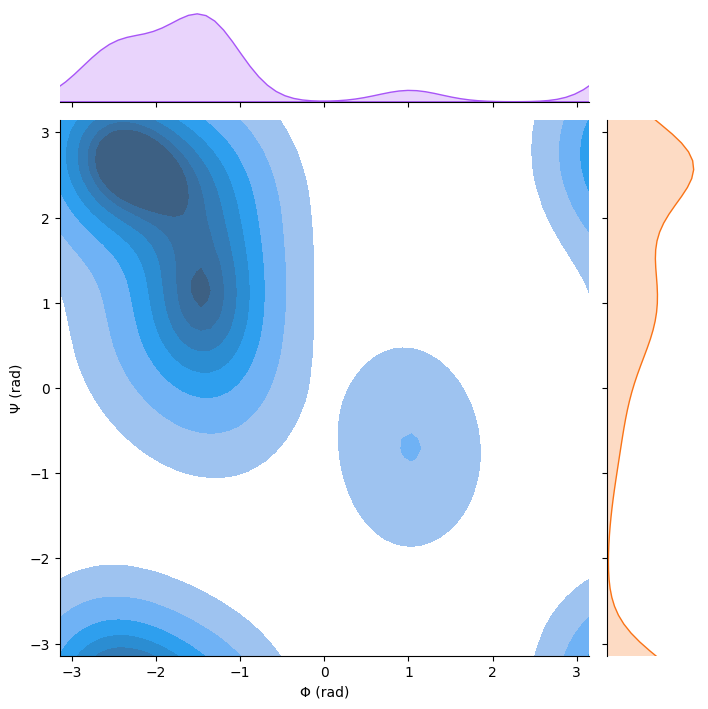

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

stride=1

data = np.vstack([data_dih['phi'],data_dih['psi']])

periodic_variables = True

if periodic_variables:
  # Tile data in both dimensions
  shifts = [-2*np.pi, 0, 2*np.pi]
  tiled_data = []
  for dx in shifts:
      for dy in shifts:
          shifted = np.vstack([data_dih['phi'] + dx, data_dih['psi'] + dy])
          tiled_data.append(shifted)

  data_used = np.hstack(tiled_data)
else:
  data_used = data

data_used = data_used[:,::stride]

x = data_used[0]
y = data_used[1]

g = sns.JointGrid(height=7, ratio=5)
ax_joint, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
sns.kdeplot(x=x, y=y,
            ax=ax_joint,
            bw_adjust=0.6,
            fill=True,
            levels=8)
ax_joint.set_xlabel(x_label)
ax_joint.set_ylabel(y_label)
sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
ax_joint.set_xlim(-np.pi, np.pi)
ax_joint.set_ylim(-np.pi, np.pi)
ax_top.set_xlim(-np.pi, np.pi)
ax_right.set_ylim(-np.pi, np.pi)
plt.show()

#B
Design criteria so that you can assign each sample from the dataset to either the  𝐶7eq  or the  𝐶7ax  state. You should use this later on to check if the embedding that you obtain correctly seperate the two differnet states.

Note: This criteria should be more advanced than what we did in Lecture 16 where we only considered if  Φ  was postive.

In [162]:
data_dih  = pd.read_csv('AlanineDipeptide_T-576K_Dihedrals.data',          sep='\s+', comment='#', header=None, names=['time','phi','psi','theta'])
data_dist = pd.read_csv('AlanineDipeptide_T-576K_HeavyAtomDistances.data', sep='\s+', comment='#', header=None)

phi = data_dih['phi'].to_numpy()
psi = data_dih['psi'].to_numpy()
X_dist = data_dist.iloc[:, 1:].values   # drop time column

cmap = mcolors.ListedColormap(['red', 'blue'])

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7011/4120948335.py:1: SyntaxWarning: invalid escape sequence '\s'
  data_dih  = pd.read_csv('AlanineDipeptide_T-576K_Dihedrals.data',          sep='\s+', comment='#', header=None, names=['time','phi','psi','theta'])
/tmp/ipykernel_7011/4120948335.py:2: SyntaxWarning: invalid escape sequence '\s'
  data_dist = pd.read_csv('AlanineDipeptide_T-576K_HeavyAtomDistances.data', sep='\s+', comment='#', header=None)


In [163]:
deg2rad = np.pi / 180
c7ax = (phi > 0) & (psi > -100*deg2rad) & (psi < 50*deg2rad)
c7eq = (phi < 0) & ((psi > 50*deg2rad) | (psi < -120*deg2rad))

data_dih['basin'] = -1
data_dih.loc[c7ax, 'basin'] = 0   # 0 = C7ax  → red
data_dih.loc[c7eq, 'basin'] = 1   # 1 = C7eq  → blue

basin = data_dih['basin'].to_numpy()
mask  = basin >= 0

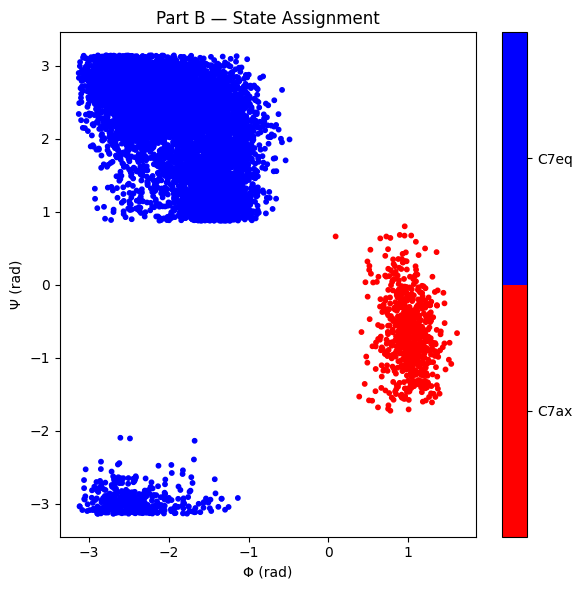

C7ax: 637 (6.4%)
C7eq: 7374 (73.7%)


In [164]:
plt.figure(figsize=(6, 6))
sc = plt.scatter(phi[mask], psi[mask], c=basin[mask], cmap=cmap, s=10)
cbar = plt.colorbar(sc, ticks=[0.25, 0.75])
cbar.ax.set_yticklabels(['C7ax', 'C7eq'])
plt.xlabel('Φ (rad)'); plt.ylabel('Ψ (rad)')
plt.title('Part B — State Assignment')
plt.tight_layout(); plt.show()

for lbl, val in [('C7ax', 0), ('C7eq', 1)]:
    n = (basin == val).sum()
    print(f"{lbl}: {n} ({100*n/len(basin):.1f}%)")

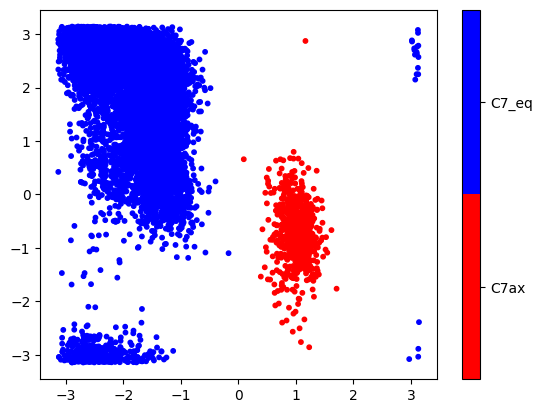

In [146]:
phi = data_dih['phi'].to_numpy()

data_dih['C7eq_basin'] = np.where( (phi > 0) & (phi < 2) ,0 , 1)

import matplotlib.colors as mcolors
cmap = mcolors.ListedColormap(['red', 'blue'])
plt.scatter(data_dih['phi'], data_dih['psi'],c=data_dih['C7eq_basin'],s=10, cmap=cmap)
cbar = plt.colorbar(ticks=[0.25,0.75])
cbar.ax.set_yticklabels(['C7ax', 'C7_eq'])
plt.show()

In [143]:
def assign_states(phi_arr, psi_arr):
    states = np.full(len(phi_arr), -1, dtype=int)  # -1 = unassigned

    # Convert degrees to radians
    deg2rad = np.pi / 180
    c7eq = (phi_arr < 0) & ((psi_arr > 50*deg2rad) | (psi_arr < -120*deg2rad))
    c7ax = (phi_arr > 0) & (psi_arr > -100*deg2rad) & (psi_arr < 50*deg2rad)

    states[c7eq] = 0
    states[c7ax] = 1
    return states

phi = datadih["phi"].to_numpy()
psi = datadih["psi"].to_numpy()
states = assign_states(phi, psi)

state_labels = {0: "C7eq", 1: "C7ax"}
total = len(states)
for k, lbl in state_labels.items():
    n = np.sum(states == k)
    print(f"{lbl}: {n:5d}  ({100*n/total:.1f}%)")

C7eq:  7374  (73.7%)
C7ax:   637  (6.4%)


# C
Perform Principal Component Analysis (PCA) for the system using all heavy atom distances as input features, and visualize the first two principle components.

Here, you should use the full dataset in the analysis (all 10000 samples).

How much of the variance is described by the first two principle components?

Use the results from B) to understand if the PCA embeddings is able to seperate the  𝐶7eq  and  𝐶7ax  states.

You should try both using unscaled and scaled distances as input features. How does this affect the results.

In [165]:
# Unscaled
pca_u = PCA()
X_pca_unscaled = pca_u.fit_transform(X_dist)

In [166]:
# Scaled
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_dist)
pca_s = PCA()
X_pca_scaled = pca_s.fit_transform(X_scaled)

print(f"\nUnscaled — PC1: {pca_u.explained_variance_ratio_[0]*100:.1f}%  PC2: {pca_u.explained_variance_ratio_[1]*100:.1f}%")
print(f"Scaled   — PC1: {pca_s.explained_variance_ratio_[0]*100:.1f}%  PC2: {pca_s.explained_variance_ratio_[1]*100:.1f}%")


Unscaled — PC1: 74.8%  PC2: 10.6%
Scaled   — PC1: 27.0%  PC2: 9.7%


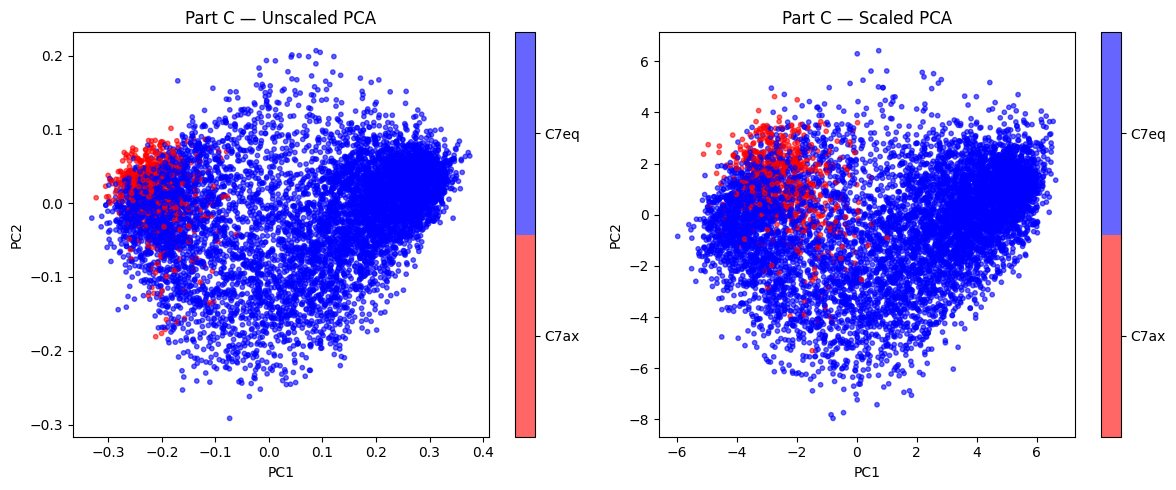

In [167]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for i, (ax, X_pca, title) in enumerate(zip(
        [ax1, ax2],
        [X_pca_unscaled, X_pca_scaled],
        ['Unscaled PCA', 'Scaled PCA'])):
    sc = ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=basin[mask], cmap=cmap, alpha=0.6, s=10)
    cbar = plt.colorbar(sc, ax=ax, ticks=[0.25, 0.75])
    cbar.ax.set_yticklabels(['C7ax', 'C7eq'])
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'Part C — {title}')
plt.tight_layout(); plt.show()

#D
Some of the heavy atom distances might not be relevant and only add noise. To address this, design criteria for filtering out distances that might not be relevant and re-do the PCA analysis. How does this affect the results?

For example, you might consider only using distances that have standard deviation above some given threshold value.

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7011/4069889361.py:7: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+', comment='#', header=None)


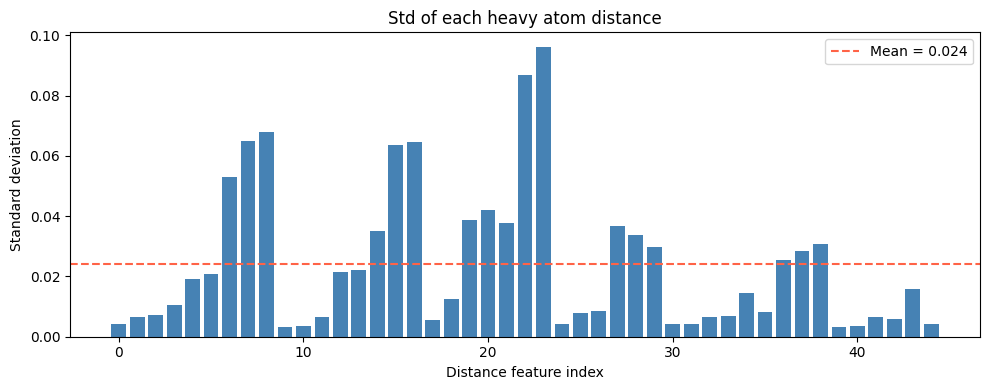

Kept 17 / 45 features


In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load distances
distances = pd.read_csv('AlanineDipeptide_T-576K_HeavyAtomDistances.data',
                        sep='\s+', comment='#', header=None)
X_dist = distances.iloc[:, 1:].values  # skip time column

# Compute std for each of the 45 distances
stds = X_dist.std(axis=0)

# Plot
plt.figure(figsize=(10, 4))
plt.bar(range(len(stds)), stds, color='steelblue')
plt.axhline(stds.mean(), color='tomato', ls='--', label=f'Mean = {stds.mean():.3f}')
plt.xlabel('Distance feature index')
plt.ylabel('Standard deviation')
plt.title('Std of each heavy atom distance')
plt.legend()
plt.tight_layout()
plt.show()

# Filter: keep only distances with std >= mean
keep = stds >= stds.mean()
X_filtered = X_dist[:, keep]
print(f"Kept {keep.sum()} / {len(stds)} features")

In [131]:
stds = X_dist.std(axis=0)

print(f"Min std:    {stds.min():.4f}")
print(f"Max std:    {stds.max():.4f}")
print(f"Mean std:   {stds.mean():.4f}")
print(f"Median std: {np.median(stds):.4f}")

Min std:    0.0032
Max std:    0.0962
Mean std:   0.0241
Median std: 0.0145


In [132]:
threshold = stds.mean()  # 0.0241

keep = stds >= threshold
X_filtered = X_dist[:, keep]
print(f"Kept {keep.sum()} / {len(stds)} features")
# Expect roughly 15-20 features kept

Kept 17 / 45 features


##Choosing threshold std.

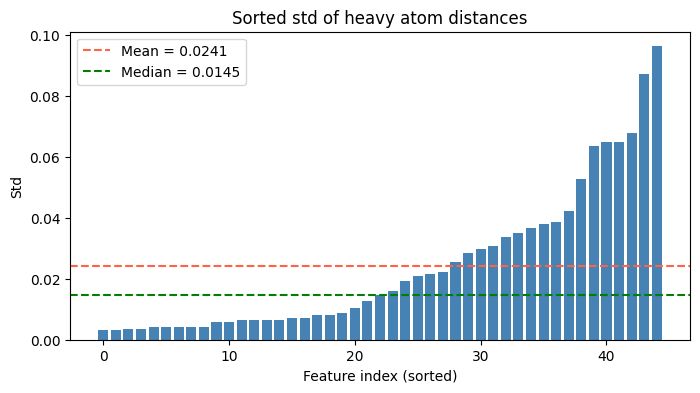

In [133]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(stds)), sorted(stds), color='steelblue')
plt.axhline(stds.mean(),   color='tomato', ls='--', label=f'Mean = {stds.mean():.4f}')
plt.axhline(np.median(stds), color='green', ls='--', label=f'Median = {np.median(stds):.4f}')
plt.xlabel('Feature index (sorted)')
plt.ylabel('Std')
plt.title('Sorted std of heavy atom distances')
plt.legend()
plt.show()

In [134]:
# Step 1: Calculate std dev for each distance
stds = X.std(axis=0)
print(f"Distance stds range: [{stds.min():.3f}, {stds.max():.3f}]")

# Step 2: Filter - keep distances with std > threshold (e.g., 0.02)# I have choosed 0.02 between mean and median
threshold = 0.02
good_features = stds > threshold
X_filtered = X[:, good_features]
print(f"Kept {X_filtered.shape[1]} / {X.shape[1]} distances (std > {threshold})")

# Step 3: Re-do scaled PCA on filtered data
scaler_f = StandardScaler()
X_f_scaled = scaler_f.fit_transform(X_filtered)
pca_filtered = PCA()
X_pca_f = pca_filtered.fit_transform(X_f_scaled)
print(f"Filtered PC1+PC2: {pca_filtered.explained_variance_ratio_[:2].sum()*100:.1f}%")

Distance stds range: [0.003, 0.096]
Kept 20 / 45 distances (std > 0.02)
Filtered PC1+PC2: 78.8%


In [168]:
stds = X_dist.std(axis=0)
threshold = 0.02
keep = stds >= threshold
X_filtered = X_dist[:, keep]
print(f"\nPart D — Kept {keep.sum()} / {X_dist.shape[1]} features (threshold={threshold})")



Part D — Kept 20 / 45 features (threshold=0.02)


In [170]:
pca_fu = PCA()
X_pca_filt_unscaled = pca_fu.fit_transform(X_filtered)


In [171]:
X_filt_scaled = StandardScaler().fit_transform(X_filtered)
pca_fs = PCA()
X_pca_filt_scaled = pca_fs.fit_transform(X_filt_scaled)

print(f"Filtered Unscaled — PC1: {pca_fu.explained_variance_ratio_[0]*100:.1f}%  PC2: {pca_fu.explained_variance_ratio_[1]*100:.1f}%")
print(f"Filtered Scaled   — PC1: {pca_fs.explained_variance_ratio_[0]*100:.1f}%  PC2: {pca_fs.explained_variance_ratio_[1]*100:.1f}%")


Filtered Unscaled — PC1: 77.4%  PC2: 10.9%
Filtered Scaled   — PC1: 59.6%  PC2: 19.2%


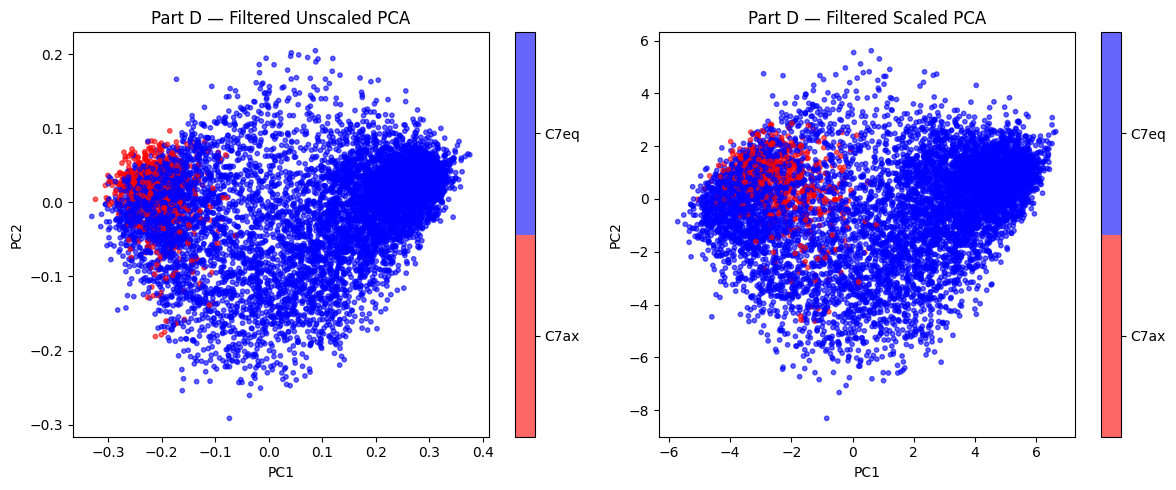

In [172]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for ax, X_pca, title in zip(
        [ax1, ax2],
        [X_pca_filt_unscaled, X_pca_filt_scaled],
        ['Filtered Unscaled PCA', 'Filtered Scaled PCA']):
    sc = ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=basin[mask], cmap=cmap, alpha=0.6, s=10)
    cbar = plt.colorbar(sc, ax=ax, ticks=[0.25, 0.75])
    cbar.ax.set_yticklabels(['C7ax', 'C7eq'])
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'Part D — {title}')
plt.tight_layout(); plt.show()


#E
Perform t-SNE analysis using the openTSNE code and obtain two-dimensional embeddings.

One feature of the openTNSE implementation of t-SNE, as compared to the scikit-learn one, is that it allows for embedding new samples into existing embeddings.

Here, you should use 10% of the dataset (1000 samples) to fit the  𝑡 -SNE embedding (for example by taking only every 10 sample), and then transform the full dataset and plot and visulize that.

Here, you should use the set of filtered distances that you used in D). I would also recommend to use scaled distances.

Here, you should consider different perplexity values in the analysis. What is optimal perplexity value in your opinion?

Once you have found the optimal perplexity value, you can you try to use the full dataset in the fitting of the  𝑡 -SNE embedding. The openTNSE implementation should more performant thant the scikit-learn one. Does this affect the results in some manner.

In [175]:
!pip install openTSNE
from openTSNE import TSNE

In [182]:
import openTSNE

X_tsne_input = StandardScaler().fit_transform(X_filtered)

# Fit on 10% subset (every 10th sample)
idx_fit = np.arange(0, len(phi), 10)
X_fit   = X_tsne_input[idx_fit]

In [183]:
X_tsne_input = StandardScaler().fit_transform(X_filtered)

# Fit on 10% subset (every 10th sample)
idx_fit = np.arange(0, len(phi), 10)
X_fit   = X_tsne_input[idx_fit]


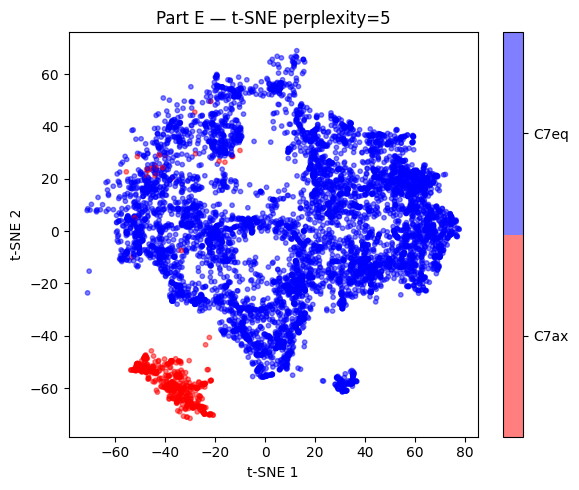

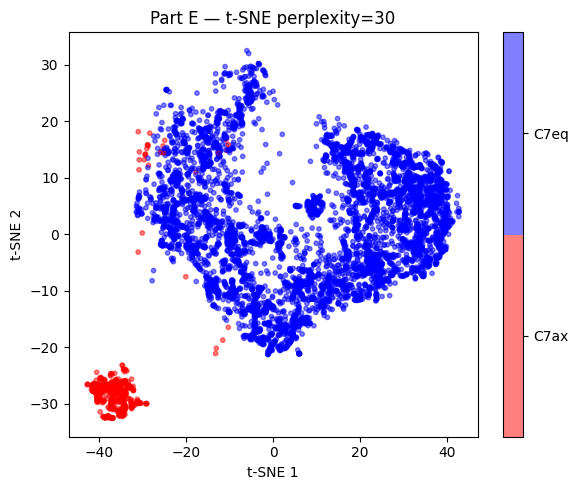

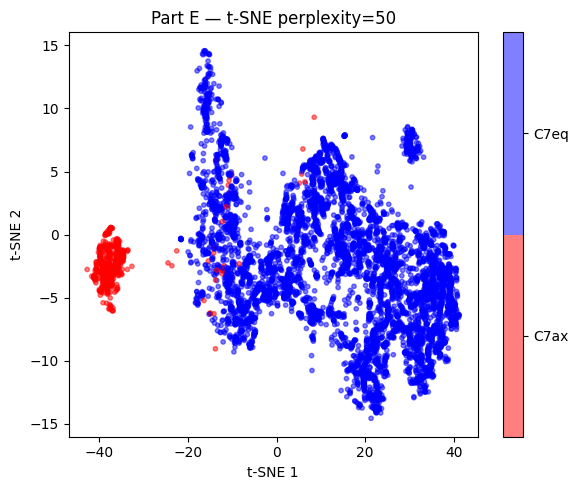

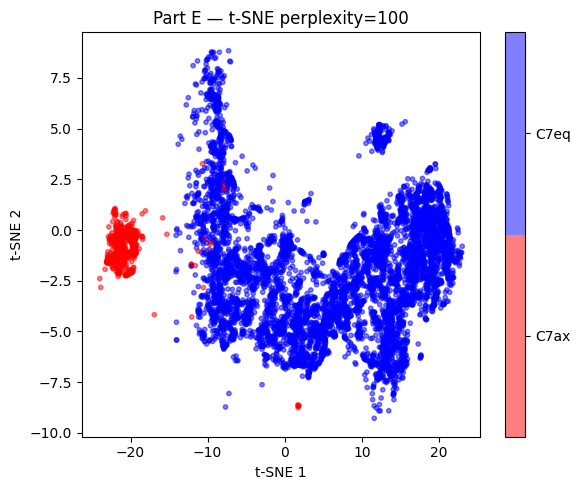

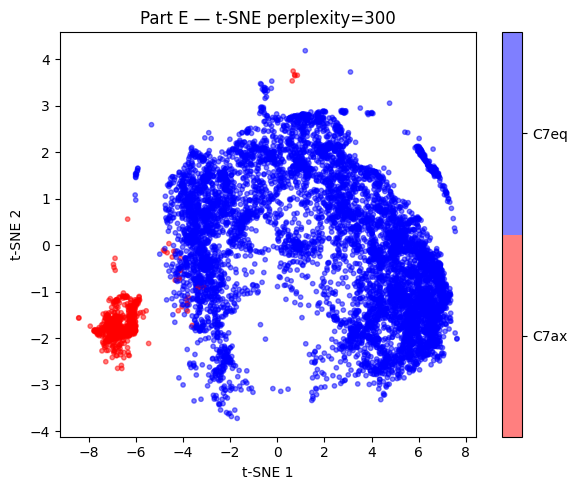

In [184]:
#Scan perplexities
for perp in [5, 30, 50, 100, 300]:
    tsne = openTSNE.TSNE(perplexity=perp, n_components=2,
                         initialization='pca', n_jobs=-1,
                         random_state=42, verbose=False)
    emb_fit  = tsne.fit(X_fit)
    emb_full = emb_fit.transform(X_tsne_input)

    plt.figure(figsize=(6, 5))
    sc = plt.scatter(emb_full[mask, 0], emb_full[mask, 1],
                     c=basin[mask], cmap=cmap, alpha=0.5, s=10)
    cbar = plt.colorbar(sc, ticks=[0.25, 0.75])
    cbar.ax.set_yticklabels(['C7ax', 'C7eq'])
    plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
    plt.title(f'Part E — t-SNE perplexity={perp}')
    plt.tight_layout(); plt.show()

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=-1, perplexity=100, random_state=42,
     verbose=True)
--------------------------------------------------------------------------------
===> Finding 300 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 13.02 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 1.65 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.01 seconds
===> Running optimization with exaggeration=12.00, lr=833.42 for 250 iterations...
Iteration   50, KL divergence 3.4249, 50 iterations in 3.1808 sec
Iteration  100, KL divergence 3.4863, 50 iterations in 3.1995 sec
Iteration  150, KL divergence 3.4929, 50 iterations in 4.6338 sec
Iteration  200, KL divergence 3.4928, 50 iterations in 3.1466 sec
Iteration  250, KL divergence 3.4928, 50 iterations in 3.1601 sec
   --> Time elapsed: 17.32 seconds
===> Running optimiza

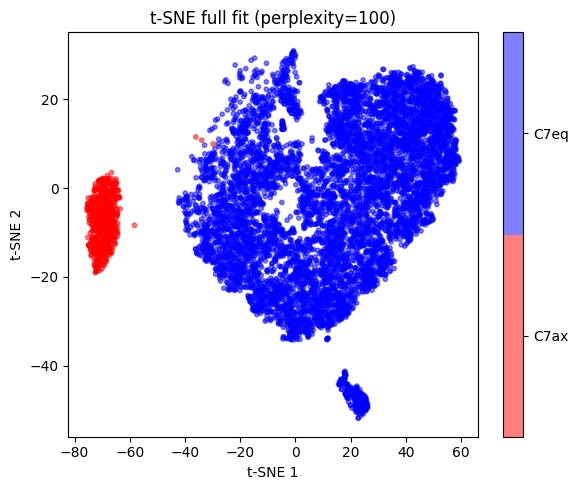

In [188]:
# Fit on full dataset with optimal perplexity
OPTIMAL_PERP = 100
tsne_full = openTSNE.TSNE(perplexity=OPTIMAL_PERP, n_components=2,
                           initialization='pca', n_jobs=-1,
                           random_state=42, verbose=True)
emb_full_fit = tsne_full.fit(X_tsne_input)

plt.figure(figsize=(6, 5))
sc = plt.scatter(emb_full_fit[mask, 0], emb_full_fit[mask, 1],
                 c=basin[mask], cmap=cmap, alpha=0.5, s=10)
cbar = plt.colorbar(sc, ticks=[0.25, 0.75])
cbar.ax.set_yticklabels(['C7ax', 'C7eq'])
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.title(f't-SNE full fit (perplexity={OPTIMAL_PERP})')
plt.tight_layout(); plt.show()

##OPTIONAL
For the t-SNE analysis, using the the optimal perplexity value, test the effect of 1) using either unscaled or scaled features; and 2) using either the filtered distances or the full set of 45 distances.

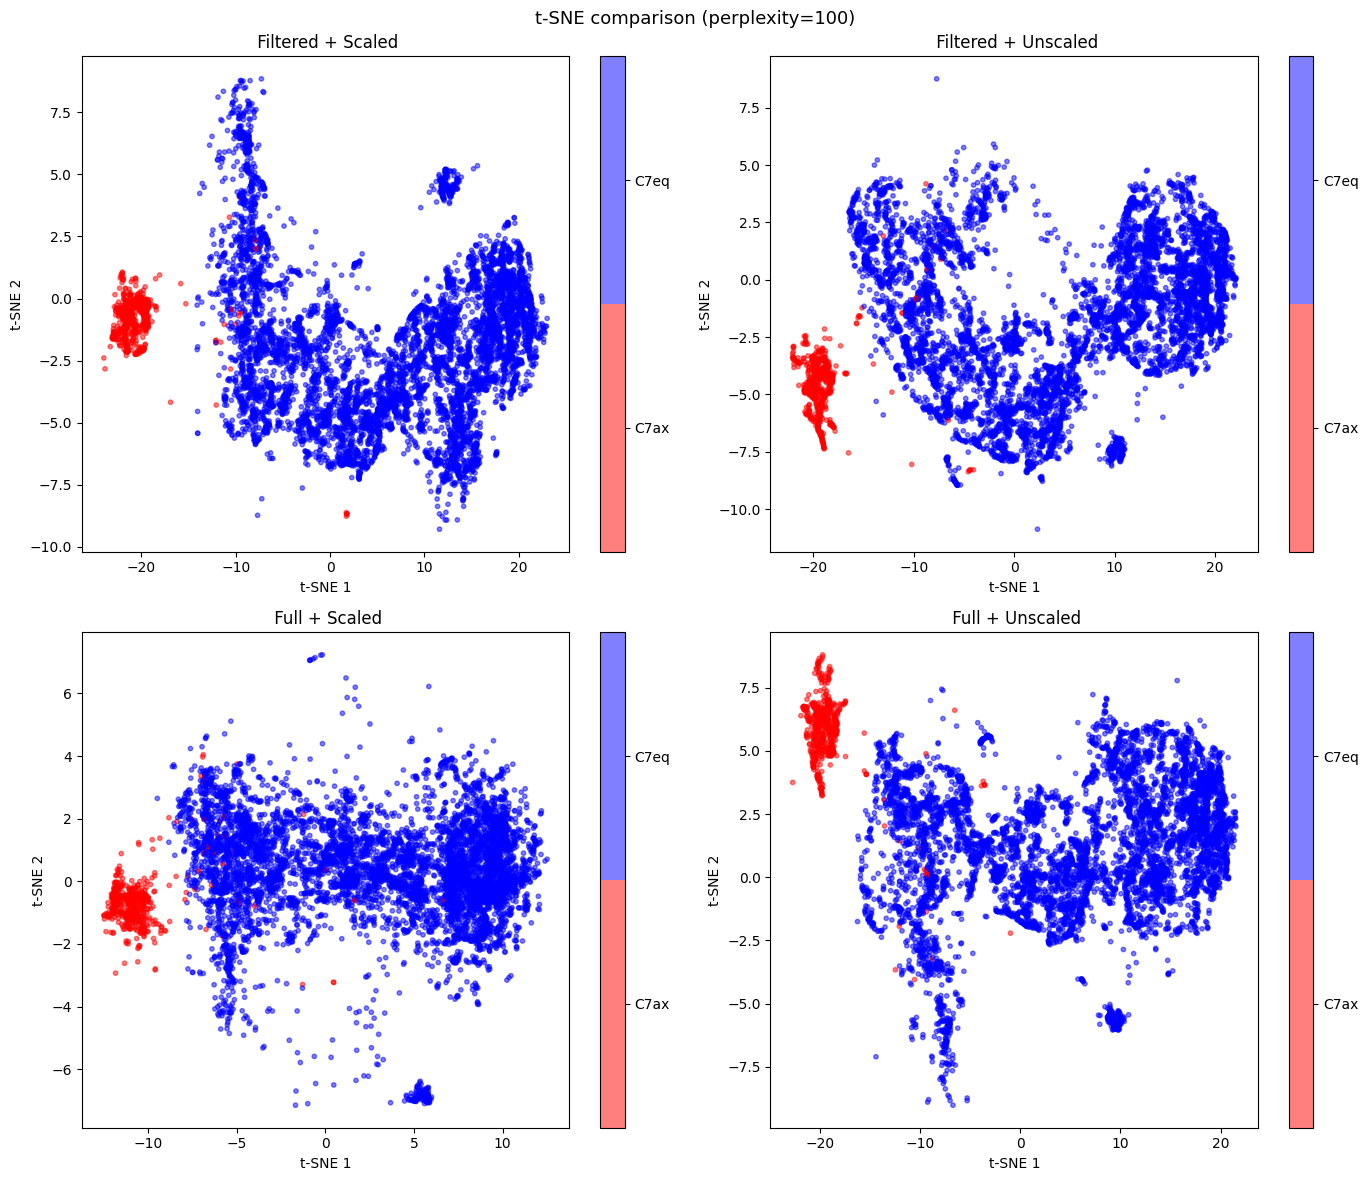

In [189]:
configs = [
    ('Filtered + Scaled',   X_filtered, True),
    ('Filtered + Unscaled', X_filtered, False),
    ('Full + Scaled',       X_dist,     True),
    ('Full + Unscaled',     X_dist,     False),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (label, X_in, scale) in zip(axes.ravel(), configs):
    X_use = StandardScaler().fit_transform(X_in) if scale else X_in
    tsne = openTSNE.TSNE(perplexity=OPTIMAL_PERP, n_components=2,
                          initialization='pca', n_jobs=-1,
                          random_state=42, verbose=False)
    emb_fit  = tsne.fit(X_use[idx_fit])
    emb_full = emb_fit.transform(X_use)
    sc = ax.scatter(emb_full[mask, 0], emb_full[mask, 1],
                    c=basin[mask], cmap=cmap, alpha=0.5, s=10)
    cbar = plt.colorbar(sc, ax=ax, ticks=[0.25, 0.75])
    cbar.ax.set_yticklabels(['C7ax', 'C7eq'])
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.set_title(f' {label}')

plt.suptitle(f't-SNE comparison (perplexity={OPTIMAL_PERP})', fontsize=13)
plt.tight_layout(); plt.show()